# Sales Prediction Model - IronKaggle Competition

This notebook builds a predictive model for sales forecasting using LightGBM and XGBoost ensemble methods.

In [2]:
# Install required libraries (run once)
%pip install lightgbm xgboost -q


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import xgboost as xgb
import lightgbm as lgb

## 1. Load and Explore Data

In [4]:
train = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/sales.csv")
test = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/ironkaggle_notarget.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nTrain columns:", train.columns.tolist())
print("Test columns:", test.columns.tolist())

Train shape: (640840, 10)
Test shape: (71205, 9)

Train columns: ['True_index', 'Store_ID', 'Day_of_week', 'Date', 'Nb_customers_on_day', 'Open', 'Promotion', 'State_holiday', 'School_holiday', 'Sales']
Test columns: ['True_index', 'Store_ID', 'Day_of_week', 'Date', 'Nb_customers_on_day', 'Open', 'Promotion', 'State_holiday', 'School_holiday']


In [5]:
train.head()

,True_index,Store_ID,Day_of_week,Date,Nb_customers_on_day,Open,Promotion,State_holiday,School_holiday,Sales
0,0,625,3,2013-11-06,641,1,1,0,0,7293
1,1,293,2,2013-07-16,877,1,1,0,1,7060
2,2,39,4,2014-01-23,561,1,1,0,0,4565
3,3,676,4,2013-09-26,1584,1,1,0,0,6380
4,4,709,3,2014-01-22,1477,1,1,0,0,11647


In [33]:
train.Open.unique()

array([1, 0])

In [34]:
train.Promotion.unique()

array([1, 0])

In [35]:
train.State_holiday.unique()

<StringArray>
['0', 'c', 'a', 'b']
Length: 4, dtype: str

#### Data Types and Missing Values and Quick EDA

Need to convert categorical columns ( State_holiday) from string/object types to numeric for model compatibility.

In [6]:
test.head()

,True_index,Store_ID,Day_of_week,Date,Nb_customers_on_day,Open,Promotion,State_holiday,School_holiday
0,7,764,4,2013-12-26,0,0,0,c,1
1,19,22,3,2013-05-22,449,1,0,0,1
2,31,1087,6,2013-06-29,622,1,0,0,0
3,45,139,6,2013-08-17,314,1,0,0,0
4,56,568,1,2014-04-07,356,1,0,0,0


In [10]:
train.dtypes

True_index             int64
Store_ID               int64
Day_of_week            int64
Date                     str
Nb_customers_on_day    int64
Open                   int64
Promotion              int64
State_holiday            str
School_holiday         int64
Sales                  int64
dtype: object

In [9]:
train.isnull().sum()

True_index             0
Store_ID               0
Day_of_week            0
Date                   0
Nb_customers_on_day    0
Open                   0
Promotion              0
State_holiday          0
School_holiday         0
Sales                  0
dtype: int64

In [12]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
True_index,640840.0,355990.675084,205536.290268,0.0,178075.75,355948.5,533959.25,712044.0
Store_ID,640840.0,558.211348,321.878521,1.0,280.00,558.0,837.00,1115.0
Day_of_week,640840.0,4.000189,1.996478,1.0,2.00,4.0,6.00,7.0
Nb_customers_on_day,640840.0,633.398577,464.094416,0.0,405.00,609.0,838.00,5458.0
Open,640840.0,0.830185,0.375470,0.0,1.00,1.0,1.00,1.0
Promotion,640840.0,0.381718,0.485808,0.0,0.00,0.0,1.00,1.0
School_holiday,640840.0,0.178472,0.382910,0.0,0.00,0.0,0.00,1.0
Sales,640840.0,5777.469011,3851.338083,0.0,3731.00,5746.0,7860.00,41551.0


In [14]:
train.Sales.describe()

count    640840.000000
mean       5777.469011
std        3851.338083
min           0.000000
25%        3731.000000
50%        5746.000000
75%        7860.000000
max       41551.000000
Name: Sales, dtype: float64

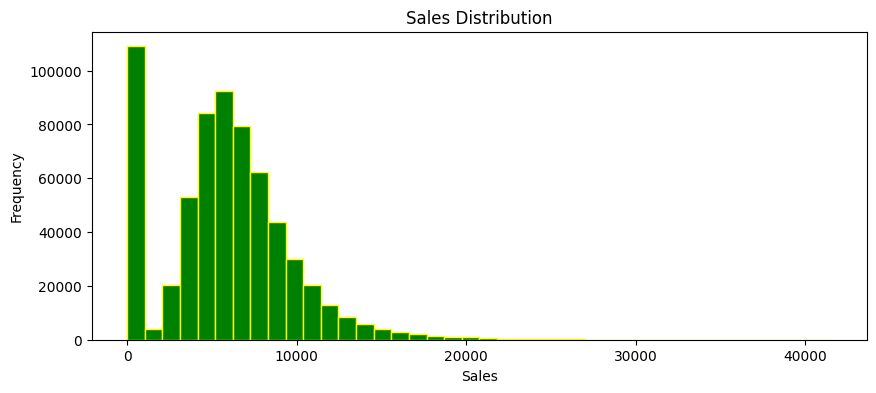

In [48]:
plt.figure(figsize=(10, 4))
plt.hist(train['Sales'], bins=40, color='green', edgecolor='yellow')
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

## 2. Feature engineering 

In [24]:
def engineer_features(data):
    d = data.copy()
    
    # Parse date
    d['Date'] = pd.to_datetime(d['Date'])
    
    # Extract time features
    d['year'] = d['Date'].dt.year
    d['month'] = d['Date'].dt.month
    d['day'] = d['Date'].dt.day
    d['week_of_year'] = d['Date'].dt.isocalendar().week.astype(int)
    d['quarter'] = d['Date'].dt.quarter
    
    # Flag features
    d['is_weekend'] = (d['Day_of_week'] >= 6).astype(int)
    d['is_month_start'] = (d['day'] <= 5).astype(int)
    d['is_month_end'] = (d['day'] >= 25).astype(int)
    
    # Encode state holiday
    d['state_holiday_enc'] = d['State_holiday'].map({'0': 0, 'a': 1, 'b': 2, 'c': 3})
    
    # Drop original date and state holiday columns
    d.drop(columns=['Date', 'State_holiday'], inplace=True)
    
    return d

#### Store-Level Aggregations

Create aggregate features at the store level to capture store-specific patterns in sales and customer behavior.

In [25]:
# open stores for aggregates
store_aggs = train[train['Open'] == 1].groupby('Store_ID').agg(
    store_mean_sales=('Sales', 'mean'),
    store_median_sales=('Sales', 'median'),
    store_std_sales=('Sales', 'std'),
    store_mean_customers=('Nb_customers_on_day', 'mean')
).reset_index()

# Mean sales per store per day of week
dow_store = train[train['Open'] == 1].groupby(['Store_ID', 'Day_of_week']).agg(
    store_dow_mean=('Sales', 'mean')
).reset_index()

print("Store aggregates shape:", store_aggs.shape)
print(store_aggs.head())

Store aggregates shape: (1115, 5)
   Store_ID  store_mean_sales  store_median_sales  store_std_sales  \
0         1       4769.382643              4676.0       986.628549   
1         2       4907.566929              4760.5      1645.602018   
2         3       6886.496000              6671.0      2163.142677   
3         4       9714.846639              9554.0      1938.199364   
4         5       4650.859470              4597.0      1683.735543   

   store_mean_customers  
0            564.493097  
1            579.322835  
2            746.586000  
3           1327.577731  
4            537.340122  


#### Apply Feature Engineering

Apply feature engineering to both train and test sets, and merge in the store aggregations.

In [26]:
train_fe = engineer_features(train)
test_fe = engineer_features(test)

# Merge store aggregates
train_fe = train_fe.merge(store_aggs, on='Store_ID', how='left')
test_fe = test_fe.merge(store_aggs, on='Store_ID', how='left')

# Merge store x day-of-week aggregates
train_fe = train_fe.merge(dow_store, on=['Store_ID', 'Day_of_week'], how='left')
test_fe = test_fe.merge(dow_store, on=['Store_ID', 'Day_of_week'], how='left')

print("Train shape after FE:", train_fe.shape)
print("Test shape after FE:", test_fe.shape)
print("\nAny NaNs in train:", train_fe.isnull().sum().sum())
print("Any NaNs in test:", test_fe.isnull().sum().sum())

Train shape after FE: (640840, 22)
Test shape after FE: (71205, 21)

Any NaNs in train: 88239
Any NaNs in test: 9847


####  Prepare Features for Modeling

Select features for training, excluding unnecessary columns like True_index and the target variable Sales.

In [38]:
# These columns we don't need for training
drop_cols = ['True_index', 'Sales']

# Feature columns = everything except drop_cols
feature_cols = [c for c in train_fe.columns if c not in drop_cols]

# X = features, y = target
X = train_fe[feature_cols]
y = train_fe['Sales']

# Test set (no Sales column)
X_test = test_fe[feature_cols]

print("Features used:", feature_cols)
print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

Features used: ['Store_ID', 'Day_of_week', 'Nb_customers_on_day', 'Open', 'Promotion', 'School_holiday', 'year', 'month', 'day', 'week_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'state_holiday_enc', 'store_mean_sales', 'store_median_sales', 'store_std_sales', 'store_mean_customers', 'store_dow_mean']

X shape: (640840, 20)
y shape: (640840,)
X_test shape: (71205, 20)


#### Train-Validation Split

Split data into training and validation sets (80-20 split) and define evaluation metrics (RMSE and RMSPE).

In [41]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for validation
    random_state=42     # reproducibility
)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rmspe(y_true, y_pred):
    # Ignore rows where actual sales = 0 (closed stores)
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))



## 3. Train LightGBM Model

Train a LightGBM gradient boosting regressor with optimized hyperparameters and early stopping.

In [42]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,       # number of trees
    learning_rate=0.05,      # how fast it learns
    num_leaves=127,          # complexity of each tree
    min_child_samples=20,    # minimum data in a leaf
    feature_fraction=0.8,    # use 80% of features per tree
    bagging_fraction=0.8,    # use 80% of data per tree
    bagging_freq=5,          # apply bagging every 5 rounds
    reg_alpha=0.1,           # L1 regularization
    reg_lambda=0.1,          # L2 regularization
    random_state=42,
    n_jobs=-1,               # use all CPU cores
    verbose=-1               # no spam output
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),  # stop if no improvement for 50 rounds
        lgb.log_evaluation(200)                  # print score every 200 rounds
    ]
)

print("LightGBM training done ✅")

[200]	valid_0's l2: 175478
[400]	valid_0's l2: 149302
[600]	valid_0's l2: 140585
[800]	valid_0's l2: 136092
[1000]	valid_0's l2: 133280
LightGBM training done ✅


#### Evaluate LightGBM Performance

Calculate validation metrics and visualize feature importance for the LightGBM model.

In [43]:
lgb_val_pred = lgb_model.predict(X_val)

print(f"LightGBM Val RMSE:  {rmse(y_val, lgb_val_pred):.2f}")
print(f"LightGBM Val RMSPE: {rmspe(y_val.values, lgb_val_pred):.4f}")

LightGBM Val RMSE:  365.07
LightGBM Val RMSPE: 0.1274


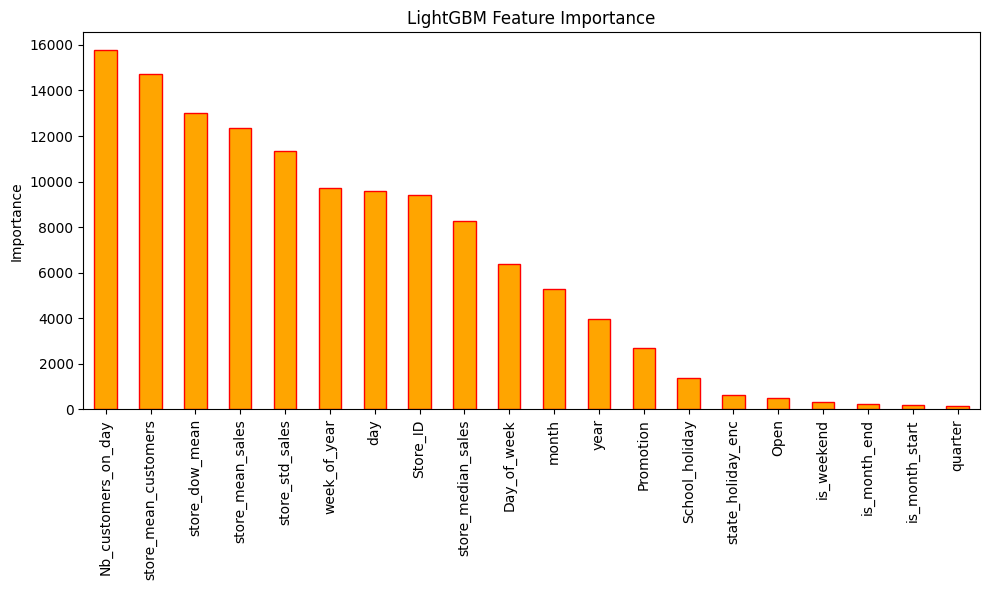

In [47]:
fi = pd.Series(lgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
fi.plot(kind='bar', color='orange', edgecolor='red')
plt.title('LightGBM Feature Importance')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## 4. Train XGBoost Model

Train an XGBoost regressor with optimized hyperparameters and early stopping for comparison.

In [49]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,        # number of trees
    learning_rate=0.05,       # how fast it learns
    max_depth=6,              # how deep each tree grows
    subsample=0.8,            # use 80% of data per tree
    colsample_bytree=0.8,     # use 80% of features per tree
    reg_alpha=0.1,            # L1 regularization
    reg_lambda=1.0,           # L2 regularization
    random_state=42,
    n_jobs=-1,                # use all CPU cores
    verbosity=0,              # no spam output
    eval_metric='rmse',
    early_stopping_rounds=50  # stop if no improvement for 50 rounds
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=200               # print score every 200 rounds
)

print("XGBoost training done ✅")

[0]	validation_0-rmse:3703.77272
[200]	validation_0-rmse:476.63810
[400]	validation_0-rmse:424.49340
[600]	validation_0-rmse:405.67296
[800]	validation_0-rmse:394.91853
[999]	validation_0-rmse:388.20104
XGBoost training done ✅


In [50]:
xgb_val_pred = xgb_model.predict(X_val)

print(f"XGBoost Val RMSE:  {rmse(y_val, xgb_val_pred):.2f}")
print(f"XGBoost Val RMSPE: {rmspe(y_val.values, xgb_val_pred):.4f}")

XGBoost Val RMSE:  388.20
XGBoost Val RMSPE: 0.1098


## 5. Ensemble Model

Combine LightGBM and XGBoost predictions using a simple averaging strategy for improved performance.

In [54]:
# Simple average of both model predictions
ensemble_val_pred = (lgb_val_pred + xgb_val_pred) / 2

print(f"Ensemble Val RMSE:  {rmse(y_val, ensemble_val_pred):.2f}")
print(f"Ensemble Val RMSPE: {rmspe(y_val.values, ensemble_val_pred):.4f}")

Ensemble Val RMSE:  369.07
Ensemble Val RMSPE: 0.1180


**Final comparison of all three models**

In [61]:
print("Final Model Comparison:")
print("-" * 25)
print(f"LightGBM  RMSE:  {rmse(y_val, lgb_val_pred):.2f}")
print(f"LightGBM  RMSPE: {rmspe(y_val.values, lgb_val_pred):.4f}")
print("-" * 25)
print(f"XGBoost   RMSE:  {rmse(y_val, xgb_val_pred):.2f}")
print(f"XGBoost   RMSPE: {rmspe(y_val.values, xgb_val_pred):.4f}")
print("-" * 25)
print(f"Ensemble  RMSE:  {rmse(y_val, ensemble_val_pred):.2f}")
print(f"Ensemble  RMSPE: {rmspe(y_val.values, ensemble_val_pred):.4f}")

Final Model Comparison:
-------------------------
LightGBM  RMSE:  365.07
LightGBM  RMSPE: 0.1274
-------------------------
XGBoost   RMSE:  388.20
XGBoost   RMSPE: 0.1098
-------------------------
Ensemble  RMSE:  369.07
Ensemble  RMSPE: 0.1180


## 6. Generate Final Predictions

Generate predictions on the test set using the ensemble model and save results to CSV.

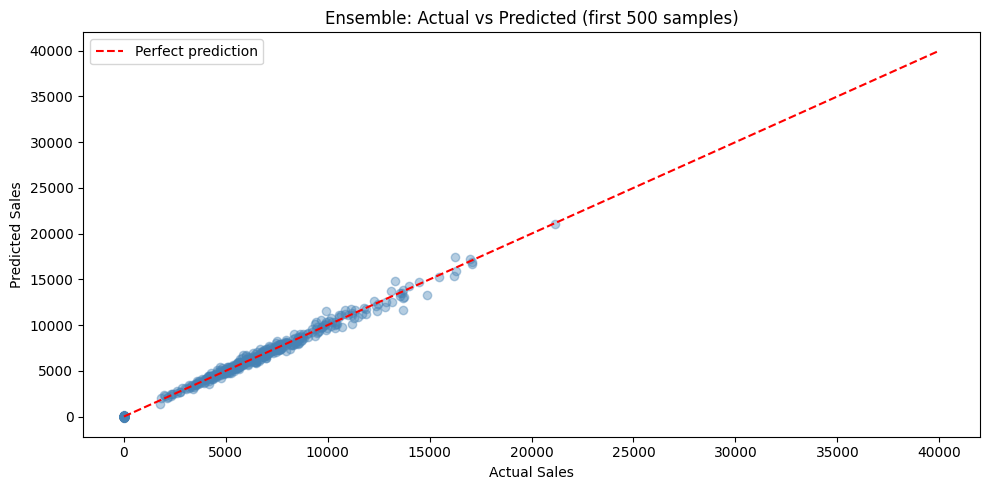

In [62]:
plt.figure(figsize=(10, 5))
plt.scatter(y_val[:500], ensemble_val_pred[:500], alpha=0.4, color='steelblue')
plt.plot([0, 40000], [0, 40000], 'r--', label='Perfect prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Ensemble: Actual vs Predicted (first 500 samples)')
plt.legend()
plt.tight_layout()
plt.show()

In [63]:
# Predict using both models
lgb_test_pred = lgb_model.predict(X_test)
xgb_test_pred = xgb_model.predict(X_test)

# Ensemble
final_pred = (lgb_test_pred + xgb_test_pred) / 2

# No negative sales!
final_pred = np.clip(final_pred, 0, None)

print("Predictions generated ✅")
print(f"Min: {final_pred.min():.0f}, Max: {final_pred.max():.0f}, Mean: {final_pred.mean():.0f}")

Predictions generated ✅
Min: 0, Max: 31976, Mean: 5767


In [65]:
prediction = pd.DataFrame({
    'True_index': test['True_index'],
    'Sales': final_pred.astype(int)
})

prediction.to_csv('predictions.csv', index=False)
